In [1]:
import numpy as np 
import pandas as pd 
import math
import random
import seaborn as sns  
import matplotlib.pyplot as plt
import scipy.stats as stats
import plotly.express as px

from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import LabelEncoder

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV 
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

from sklearn.cluster import KMeans

**1. Load  data**

In [2]:
gender_submission = pd.read_csv('../input/titanic/gender_submission.csv')
test = pd.read_csv('../input/titanic/test.csv')
train = pd.read_csv('../input/titanic/train.csv')

**2. Feature Exploration, Engineering and Cleaning**

*We create an index and remove the spaces in the data frame that we need to restore the age data of the remaining passengers. Add some new attributes such as the name length, whether the passenger had his own cabin and the deck number on which this cabin was*

In [3]:
X_train = train.reset_index()
X_test = test.reset_index()
Y = train.Survived

X_dropna = X_train.dropna()
X_test_dropna = X_test.dropna()

Dframe = [X_train, X_test]

In [4]:
print(X_train.shape, X_test.shape)

(891, 13) (418, 12)


In [5]:
print(X_train.isnull().sum())
print(X_test.isnull().sum())

index            0
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64
index            0
PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64


In [6]:
for frame in Dframe:
    
    frame['Title'] = frame.Name.str.split(',').str[1].str.split('.').str[0].str.strip()
    frame['Title'] = frame['Title'].replace('Ms','Miss')
    frame['Title'] = frame['Title'].replace('Mlle','Miss')
    frame['Title'] = frame['Title'].replace('Mme','Mrs')

    frame['famous_cabin'] = frame["Cabin"].apply(lambda x: 0 if type(x) == float else 1)
    frame['Deck'] = frame['Cabin'].apply(lambda s: s[0] if pd.notnull(s) else 'M')
    frame.loc[(frame['Deck'] == 'T'), 'Deck'] = 'A'
    
    frame['IsWomanOrBoy'] = ((frame.Title == 'Master') | (frame.Sex == 'female'))
    
    frame['FamilySize'] = frame['SibSp'] + frame['Parch'] + 1
    frame['IsAlone'] = 0
    frame.loc[frame['FamilySize'] == 1, 'IsAlone'] = 1
    
    frame['Embarked'] = frame['Embarked'].fillna('S')
    frame['Fare'] = frame['Fare'].fillna(frame['Fare'].median())
    
    frame['Name_length'] = frame['Name'].apply(len)

In [7]:
X_train.head(2)

,index,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,famous_cabin,Deck,IsWomanOrBoy,FamilySize,IsAlone,Name_length
0,0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Mr,0,M,False,2,0,23
1,1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Mrs,1,C,True,2,0,51


In [8]:
X_test.head(2)

,index,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,famous_cabin,Deck,IsWomanOrBoy,FamilySize,IsAlone,Name_length
0,0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q,Mr,0,M,False,1,1,16
1,1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S,Mrs,0,M,True,2,0,32


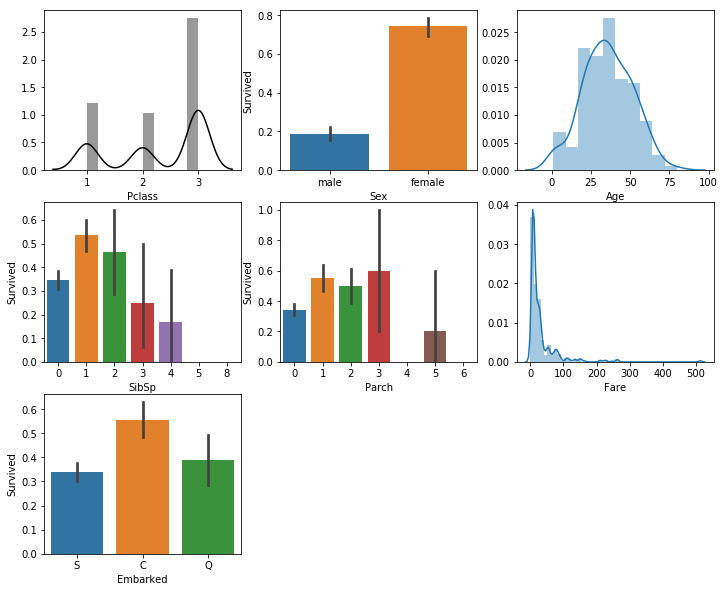

In [9]:
plt.figure(figsize=[12,10])

plt.subplot(331)
sns.distplot(X_train['Pclass'], color="k")

plt.subplot (332)                         
sns.barplot('Sex', 'Survived', data=X_train)

plt.subplot (333)
sns.distplot(X_dropna['Age']) 

plt.subplot (334)
#sns.distplot(X['SibSp'])
sns.barplot('SibSp', 'Survived', data=X_train)

plt.subplot (335)
sns.barplot('Parch', 'Survived', data=X_train)

plt.subplot (336)
sns.distplot(X_train['Fare'])
#train['Fare'].hist()

plt.subplot (337)
sns.barplot('Embarked', 'Survived', data=X_train)

**3. Recover Missed Values**

*Initially, we divide the sample into 4 subsamples of surviving men and women and non-survivors. Next, we find the mean and standard deviations for each subsample, we need them to find the confidence interval for the location of the mean from the population.*

In [10]:
X_dropna_categor = pd.get_dummies(X_dropna) 
Xtest_dropna_categor = pd.get_dummies(X_test_dropna) 

# Surviving girls:
Sex_female_Survived = X_dropna_categor.loc[(X_dropna_categor.Sex_female == 1) & (X_dropna_categor.Survived == 1)]
# Dead girls:
Sex_female_NoSurvived = X_dropna_categor.loc[(X_dropna_categor.Sex_female == 1) & (X_dropna_categor.Survived == 0)]
# Surviving guys:
X_Sex_male_Survived = X_dropna_categor.loc[(X_dropna_categor.Sex_male == 1) & (X_dropna_categor.Survived == 1)] 
# Dead guys:
X_Sex_male_NoSurvived = X_dropna_categor.loc[(X_dropna_categor.Sex_male == 1) & (X_dropna_categor.Survived == 0)]

X_test_male = Xtest_dropna_categor.loc[Xtest_dropna_categor.Sex_male == 1]
X_test_female = Xtest_dropna_categor.loc[Xtest_dropna_categor.Sex_female == 1]

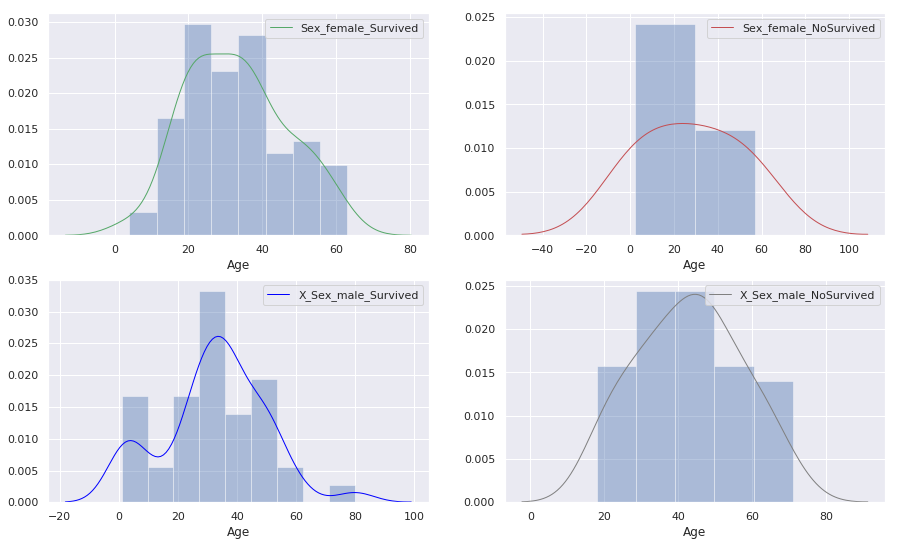

In [11]:
# age distribution of survivors and non-survivors:
sns.set(rc={'figure.figsize': (15, 9)})
plt.subplot (221)
sns.distplot(Sex_female_Survived['Age'] , kde_kws = {'color': 'g', 'lw':1, 'label': 'Sex_female_Survived' })
plt.subplot (222)
sns.distplot(Sex_female_NoSurvived['Age'] , kde_kws = {'color': 'r', 'lw':1, 'label': 'Sex_female_NoSurvived' })
plt.subplot (223)
sns.distplot(X_Sex_male_Survived['Age'] , kde_kws = {'color': 'blue', 'lw':1, 'label': 'X_Sex_male_Survived' })
plt.subplot (224)
sns.distplot(X_Sex_male_NoSurvived['Age'] , kde_kws = {'color': 'gray', 'lw':1, 'label': 'X_Sex_male_NoSurvived' })

In [12]:
class Confidence_interval(BaseEstimator, TransformerMixin):
    
    def __init__(self, index_isnull, group_age):
        self.index_isnull = index_isnull
        self.group_age = group_age
        
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        mean = self.group_age['Age'].mean()
        std = self.group_age['Age'].std()
        shape = self.group_age['Age'].shape[0]
        standard_error_ofthe_mean = std / math.sqrt(shape)
        
        for i in self.index_isnull:
            random_mean = random.uniform(
                mean-(1.96*standard_error_ofthe_mean), 
                mean+(1.96*standard_error_ofthe_mean))
            X.at[i, 'Age'] = int(random_mean) 
         
        return X

In [13]:
confidence_interval_age_pipeline_female_Survived = Pipeline([
        ('confidence_interval', Confidence_interval(X_train.loc[
            (X_train['Sex']=='female') & 
            (X_train['Survived']==1) & 
            (X_train['Age'].isnull())].index, Sex_female_Survived))
    ])


confidence_interval_age_pipeline_female_NoSurvived = Pipeline([
        ('confidence_interval', Confidence_interval(X_train.loc[
            (X_train['Sex']=='female') & 
            (X_train['Survived']==0) & 
            (X_train['Age'].isnull())].index, Sex_female_NoSurvived))
    ])

confidence_interval_age_pipeline_male_Survived = Pipeline([
        ('confidence_interval', Confidence_interval(X_train.loc[
            (X_train['Sex']=='male') & 
            (X_train['Survived']==1) & 
            (X_train['Age'].isnull())].index, X_Sex_male_Survived))
    ])

confidence_interval_age_pipeline_male_NoSurvived = Pipeline([
        ('confidence_interval', Confidence_interval(X_train.loc[
            (X_train['Sex']=='male') & 
            (X_train['Survived']==0) & 
            (X_train['Age'].isnull())].index, X_Sex_male_NoSurvived))
    ])


confidence_interval_age_pipeline_test_male = Pipeline([
        ('confidence_interval', Confidence_interval(X_test.loc[
            (X_test['Sex']=='male') & 
            (X_test['Age'].isnull())].index, X_test_male))
    ])

confidence_interval_age_pipeline_test_female = Pipeline([
        ('confidence_interval', Confidence_interval(X_test.loc[
            (X_test['Sex']=='female') & 
            (X_test['Age'].isnull())].index, X_test_female))
    ])


In [14]:
full_pipeline_train = FeatureUnion(transformer_list=[
        ("confidence_interval_age_pipeline_female_Survived", confidence_interval_age_pipeline_female_Survived),
        ("confidence_interval_age_pipeline_female_NoSurvived", confidence_interval_age_pipeline_female_NoSurvived),
        ("confidence_interval_age_pipeline_male_Survived", confidence_interval_age_pipeline_male_Survived),
        ("confidence_interval_age_pipeline_male_NoSurvived", confidence_interval_age_pipeline_male_NoSurvived)
    ])

full_pipeline_test = FeatureUnion(transformer_list=[
        ("confidence_interval_age_pipeline_test_male", confidence_interval_age_pipeline_test_male),
        ("confidence_interval_age_pipeline_test_female", confidence_interval_age_pipeline_test_female)
    ])

In [15]:
X_train = pd.DataFrame(full_pipeline_train.fit_transform(X_train)[:,:20], columns=X_train.columns)
X_test = pd.DataFrame(full_pipeline_test.fit_transform(X_test)[:,:19], columns=X_test.columns)

In [16]:
X_test['Age']  = X_test['Age'].astype(int)
X_train['Age']  = X_train['Age'].astype(int)

In [17]:
print(X_train.isnull().sum())
print(X_test.isnull().sum())

index             0
PassengerId       0
Survived          0
Pclass            0
Name              0
Sex               0
Age               0
SibSp             0
Parch             0
Ticket            0
Fare              0
Cabin           687
Embarked          0
Title             0
famous_cabin      0
Deck              0
IsWomanOrBoy      0
FamilySize        0
IsAlone           0
Name_length       0
dtype: int64
index             0
PassengerId       0
Pclass            0
Name              0
Sex               0
Age               0
SibSp             0
Parch             0
Ticket            0
Fare              0
Cabin           327
Embarked          0
Title             0
famous_cabin      0
Deck              0
IsWomanOrBoy      0
FamilySize        0
IsAlone           0
Name_length       0
dtype: int64


In [18]:
X_train = X_train.drop(['Survived', 'Name', 'Ticket', 'Cabin', 'index', 'PassengerId'], axis=1) 
X_test = X_test.drop(['Name', 'Ticket', 'Cabin', 'index', 'PassengerId'], axis=1)

**4. Translation of categorical features**

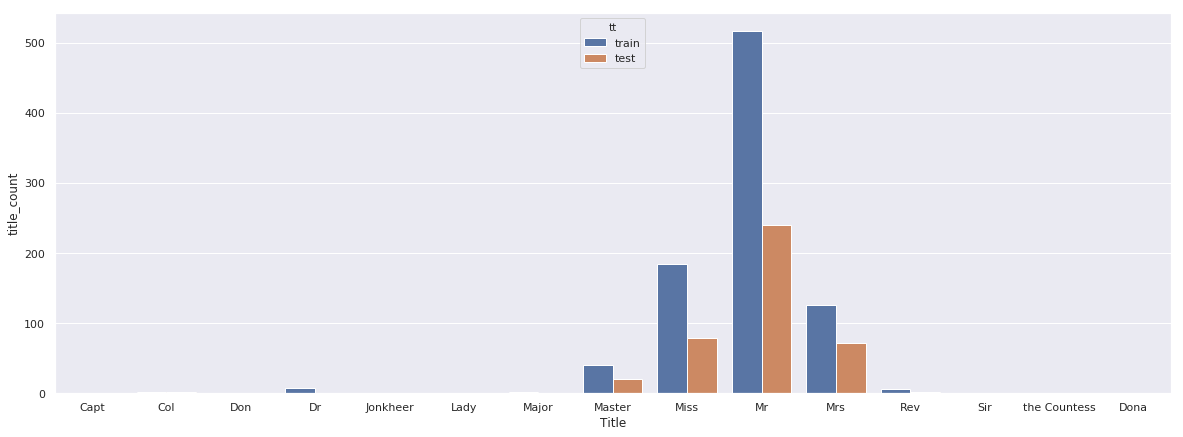

In [19]:
sns.set(rc={'figure.figsize': (20, 7)})
title_count = pd.concat([X_train.groupby('Title').aggregate({'Title': 'count'}).
                         rename(columns={'Title': 'title_count'}).reset_index(),
                          X_test.groupby('Title').aggregate({'Title': 'count'}).
                         rename(columns={'Title': 'title_count'}).reset_index()])

title_count['tt'] = ['train']*14 + ['test']*8

ax = sns.barplot(x="Title", y="title_count", hue="tt", data=title_count)

In [20]:
categorical_columns_train = ['Sex', 'Embarked', 'Deck', 'IsWomanOrBoy']

In [21]:
one_hot_train = pd.get_dummies(X_train[categorical_columns_train])
one_hot_test = pd.get_dummies(X_test[categorical_columns_train])

X_train = pd.concat([X_train, one_hot_train], axis=1)
X_test = pd.concat([X_test, one_hot_test], axis=1)

X_train = X_train.drop(categorical_columns_train, axis=1)
X_test = X_test.drop(categorical_columns_train, axis=1)
print(X_train.shape, X_test.shape)

(891, 25) (418, 25)


In [22]:
le = LabelEncoder()
le.fit(list(X_train['Title'].astype(str).values) + list(X_test['Title'].astype(str).values))
X_train['Title'] = le.transform(list(X_train['Title'].astype(str).values))
X_test['Title'] = le.transform(list(X_test['Title'].astype(str).values))  
print(X_train.shape, X_test.shape)

(891, 25) (418, 25)


In [23]:
def pearson_correlation(dataset):
    cor_map = plt.cm.RdBu
    plt.figure(figsize=(15,17))
    plt.title('Pearson Correlation', y=1.05, size=15)
    sns.heatmap(round(dataset.astype(float).corr(), 1),linewidths=0.1,vmax=1.0, 
                square=True, cmap=cor_map, linecolor='white', annot=True) 

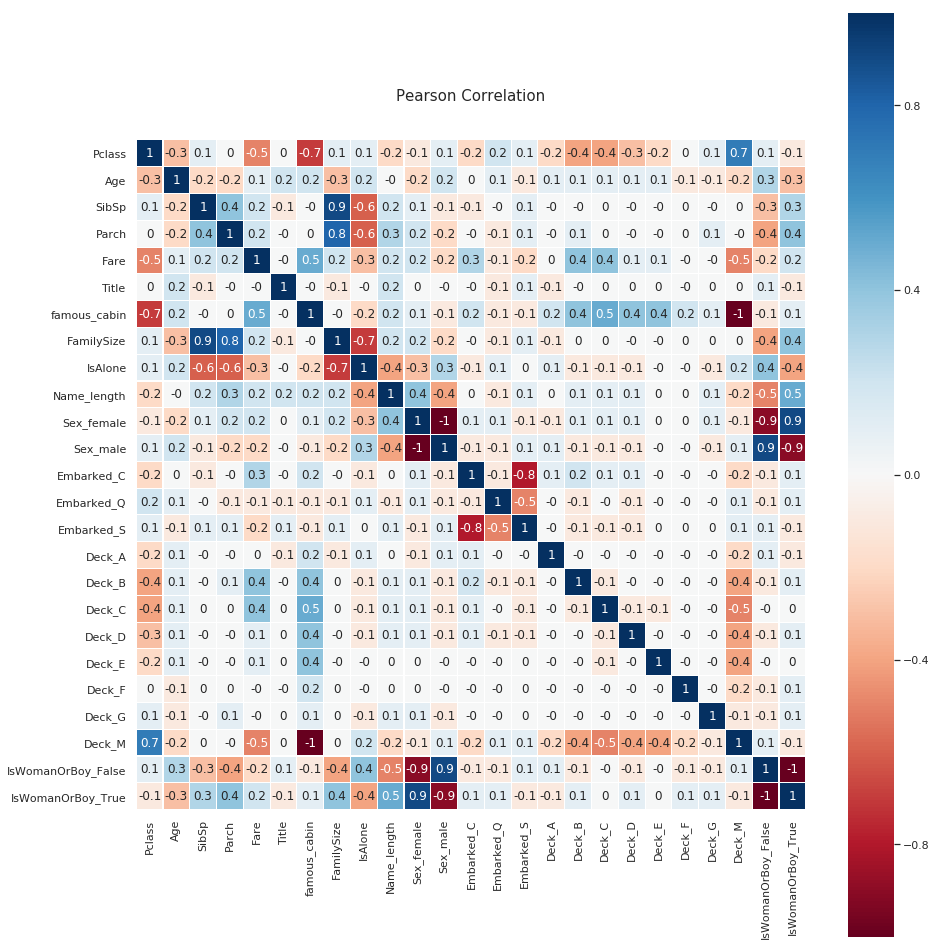

In [24]:
pearson_correlation(X_train)

In [25]:
X_train = X_train.astype(float)
X_test = X_test.astype(float)

In [26]:
def correlation(dataset, threshold):
    col_corr = set() 
    corr_matrix = dataset.corr(method='pearson')
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if threshold>0:
                if corr_matrix.iloc[i, j] >= threshold:
                    colname = corr_matrix.columns[i] 
                    col_corr.add(colname)
            elif corr_matrix.iloc[i, j] <= threshold:
                colname = corr_matrix.columns[i] 
                col_corr.add(colname)
    return col_corr

In [27]:
correlation_train = correlation(X_train, 0.7)
correlation_test = correlation(X_test, 0.7)

X_train = X_train.drop(set(list(correlation_train) + list(correlation_test)), axis=1)
X_test = X_test.drop(set(list(correlation_train) + list(correlation_test)), axis=1)

correlation_train = correlation(X_train, -0.7)
correlation_test = correlation(X_test, -0.7)

X_train = X_train.drop(set(list(correlation_train) + list(correlation_test)), axis=1)
X_test = X_test.drop(set(list(correlation_train) + list(correlation_test)), axis=1)
print(X_train.shape, X_test.shape)

(891, 18) (418, 18)


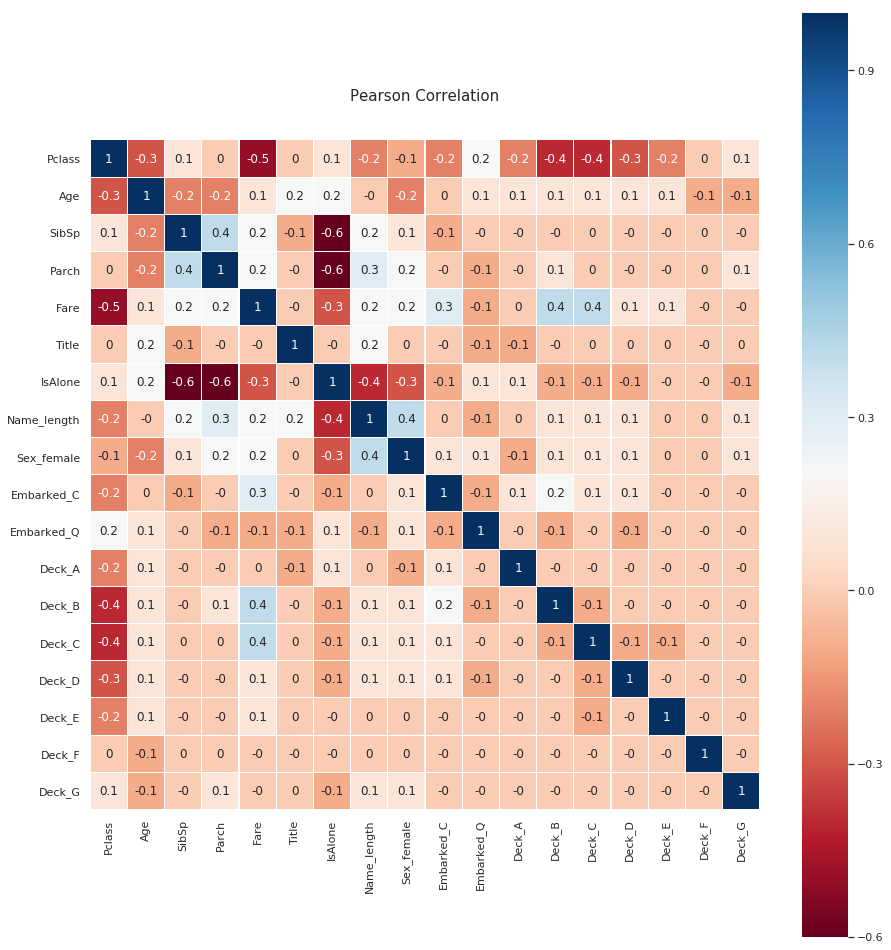

In [28]:
pearson_correlation(X_train)

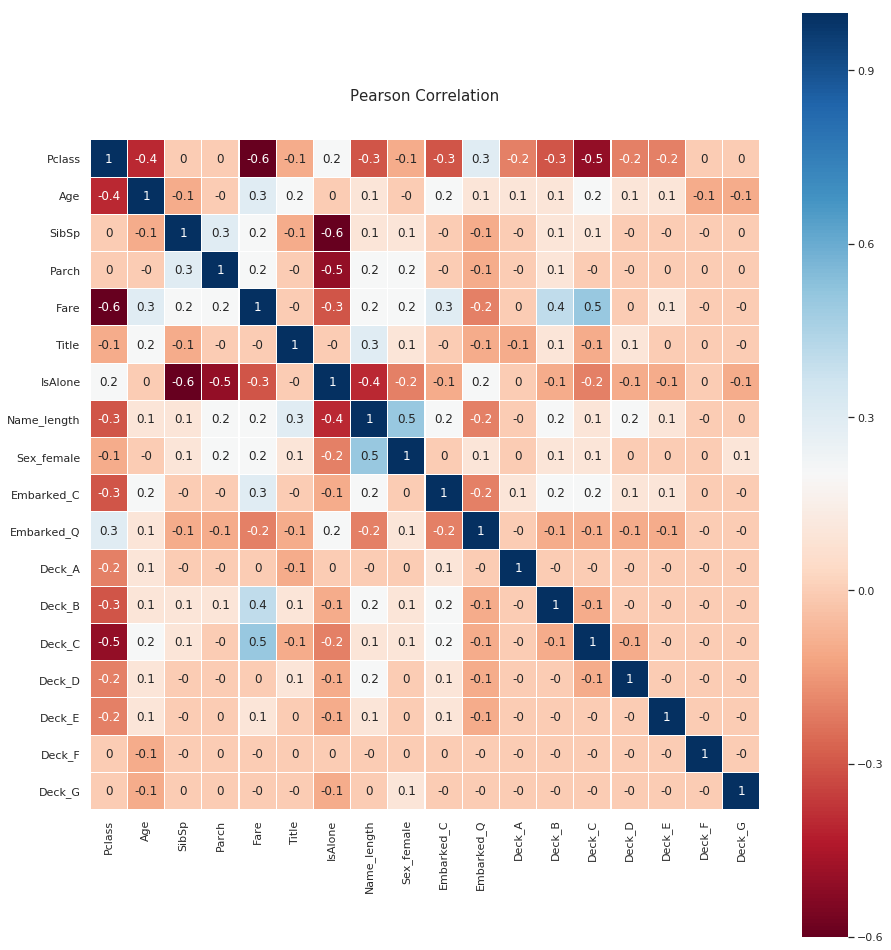

In [29]:
pearson_correlation(X_test)

**6.Classification**


In [30]:
modelrf = RandomForestClassifier(n_estimators=600, min_samples_split=40,min_samples_leaf=5,
                                max_features='auto', max_depth=7, criterion='entropy', bootstrap=False)

In [31]:
modelrf.fit(X_train, Y)
predict = modelrf.predict(X_test) 

In [32]:
submission = pd.DataFrame.from_dict({'PassengerId': list(test.PassengerId), 
                                     'Survived': list(predict)})
submission.to_csv("submission.csv", index=False)

Thank you, if you liked it, look at my second work  from a notebook: Titanic: random forest

https://www.kaggle.com/morenovanton/titanic-random-forest